# Unit 5 — 04: Detecting Data Drift in Production

**What you will do:** Apply three statistical methods to detect when the distribution of production data is shifting away from training data — KS test, Population Stability Index (PSI), and Jensen-Shannon divergence.

**Why it matters:** A model can look healthy (no errors, normal latency) while silently degrading because it is being asked to predict on data it has never seen before. Drift detection catches this early.

**How to run:** Python 3.10+. Run cells in order.

---

## Section 1 — Data Drift vs Concept Drift

**Data drift (covariate shift):** The distribution of input features P(X) changes, but the relationship between inputs and outputs P(Y|X) remains the same.  
Example: A fraud detection model trained on desktop transactions starts receiving mostly mobile transactions. Feature distributions shift (session length, device type) even though fraud still looks the same.

**Concept drift:** The relationship P(Y|X) itself changes — the same features now mean something different.  
Example: A credit scoring model trained before a recession. After the recession, the same income and debt ratios no longer predict default the same way.

**Why the distinction matters:** Data drift can sometimes be handled by retraining on more diverse data. Concept drift may require rethinking the features entirely.

## Section 2 — Kolmogorov-Smirnov Test for Numerical Features

The KS test measures the maximum difference between two cumulative distribution functions.  
- `p-value < 0.05` means the two samples are significantly different — drift is likely.
- `ks_stat` tells you how large the shift is (0 = identical, 1 = completely different).

KS statistic: 0.2360
p-value:      0.000000
Conclusion:   DRIFT DETECTED


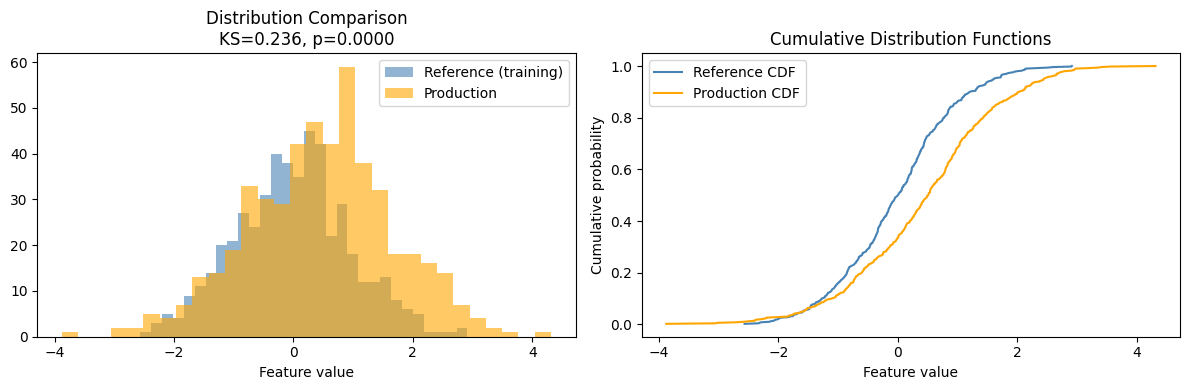

The KS statistic is the maximum vertical gap between the two CDF lines.


In [1]:
# WHAT: introduce the Kolmogorov-Smirnov test on two synthetic distributions,
# with histograms and the CDFs the test actually compares.
# WHY: KS is the workhorse of drift detection — one number (max CDF gap) plus
# a p-value that an automated monitor can threshold.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

rng = np.random.default_rng(42)

# Reference distribution: normal(0, 1)
reference = rng.normal(loc=0.0, scale=1.0, size=500)

# Production distribution: shifted to normal(0.5, 1.2)
production = rng.normal(loc=0.5, scale=1.2, size=500)

ks_stat, p_value = sp_stats.ks_2samp(reference, production)
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value:      {p_value:.6f}")
print(f"Conclusion:   {'DRIFT DETECTED' if p_value < 0.05 else 'No significant drift'}")

# Visualise the two distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reference, bins=30, alpha=0.6, label="Reference (training)", color="steelblue")
axes[0].hist(production, bins=30, alpha=0.6, label="Production", color="orange")
axes[0].set_title(f"Distribution Comparison\nKS={ks_stat:.3f}, p={p_value:.4f}")
axes[0].legend()
axes[0].set_xlabel("Feature value")

# Cumulative distributions (what KS test actually compares)
ref_sorted = np.sort(reference)
prod_sorted = np.sort(production)
ref_cdf = np.arange(1, len(ref_sorted) + 1) / len(ref_sorted)
prod_cdf = np.arange(1, len(prod_sorted) + 1) / len(prod_sorted)
axes[1].plot(ref_sorted, ref_cdf, label="Reference CDF", color="steelblue")
axes[1].plot(prod_sorted, prod_cdf, label="Production CDF", color="orange")
axes[1].set_title("Cumulative Distribution Functions")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("Cumulative probability")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/drift_ks_basic.png", dpi=72)
plt.show()
print("The KS statistic is the maximum vertical gap between the two CDF lines.")

## Section 3 — Apply KS Test to Iris Features

Simulate 200 production samples with a gradual shift. Run KS test per feature to see which features drift first.

In [2]:
# WHAT: apply the KS test per FEATURE — training data vs a simulated production
# batch whose drift grows gradually.
# WHY: real drift rarely hits all features equally; per-feature tests tell you
# WHICH input changed, the first clue to the root cause.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

feature_names = iris.feature_names

# Simulate production samples with increasing drift
N_PROD = 200
drift_levels = np.linspace(0, 1.5, N_PROD)  # drift grows gradually
# X_test has fewer than N_PROD rows, so sample with replacement to build the
# production batch, then add gradually increasing drift to each sample.
idx = rng.integers(0, len(X_test), size=N_PROD)
X_prod = X_test[idx].copy()
for i in range(N_PROD):
    X_prod[i] = X_prod[i] + drift_levels[i] * rng.normal(0, 0.5, size=4)

# One row per feature: statistic, p-value, and the drift verdict at alpha=0.05.
print("KS test results per feature (reference=training, production=shifted):")
print(f"{'Feature':<30} {'KS stat':<12} {'p-value':<12} {'Drift?'}")
print("-" * 65)
ks_results = []
for i, name in enumerate(feature_names):
    ks_stat, p_val = sp_stats.ks_2samp(X_train[:, i], X_prod[:, i])
    drifted = p_val < 0.05
    ks_results.append({"feature": name, "ks_stat": ks_stat, "p_value": p_val, "drifted": drifted})
    print(f"{name:<30} {ks_stat:<12.4f} {p_val:<12.4f} {'YES' if drifted else 'no'}")

KS test results per feature (reference=training, production=shifted):
Feature                        KS stat      p-value      Drift?
-----------------------------------------------------------------
sepal length (cm)              0.1094       0.4130       no
sepal width (cm)               0.1889       0.0204       YES
petal length (cm)              0.1083       0.4255       no
petal width (cm)               0.1828       0.0272       YES


## Section 4 — Population Stability Index (PSI) for Categorical Features

PSI compares the distribution of a categorical variable between reference and production:
- PSI < 0.1 → no meaningful drift
- 0.1 ≤ PSI < 0.2 → some drift, investigate
- PSI ≥ 0.2 → significant drift, action required

In [3]:
# WHAT: compute the Population Stability Index (PSI) on the model's PREDICTED
# class distribution — reference vs production.
# WHY: PSI monitors the model's OUTPUT side: if the class mix shifts, either the
# world changed or the model is misreading it — both worth an alert. The
# 0.1 / 0.2 bands are the standard industry interpretation.
from sklearn.ensemble import RandomForestClassifier


def compute_psi(reference_counts: np.ndarray, production_counts: np.ndarray) -> float:
    """
    Compute Population Stability Index from raw counts.
    Adds a small epsilon to avoid log(0).
    """
    eps = 1e-6
    ref_pct  = reference_counts  / reference_counts.sum()  + eps
    prod_pct = production_counts / production_counts.sum() + eps
    psi = float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))
    return psi


# Train a model and compare class prediction distribution between reference and production
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

ref_preds  = clf.predict(X_test)   # predictions on clean test data
prod_preds = clf.predict(X_prod)   # predictions on drifted production data

n_classes = len(iris.target_names)
ref_counts  = np.array([np.sum(ref_preds  == c) for c in range(n_classes)], dtype=float)
prod_counts = np.array([np.sum(prod_preds == c) for c in range(n_classes)], dtype=float)

psi_score = compute_psi(ref_counts, prod_counts)
print(f"Class distribution PSI: {psi_score:.4f}")
if psi_score < 0.1:
    print("Interpretation: No significant drift")
elif psi_score < 0.2:
    print("Interpretation: Some drift — investigate")
else:
    print("Interpretation: Significant drift — action required")

print("\nPrediction class distribution:")
print(f"{'Class':<15} {'Reference':>12} {'Production':>12}")
for i, name in enumerate(iris.target_names):
    ref_pct  = ref_counts[i]  / ref_counts.sum()  * 100
    prod_pct = prod_counts[i] / prod_counts.sum() * 100
    print(f"{name:<15} {ref_pct:>11.1f}% {prod_pct:>11.1f}%")

Class distribution PSI: 0.0082
Interpretation: No significant drift

Prediction class distribution:
Class              Reference   Production
setosa                 38.3%        34.0%
versicolor             33.3%        35.5%
virginica              28.3%        30.5%


## Section 5 — Drift Over Time (Sliding Window)

In production, drift accumulates gradually. A sliding window lets you track the KS statistic over time and see exactly when the drift becomes significant.

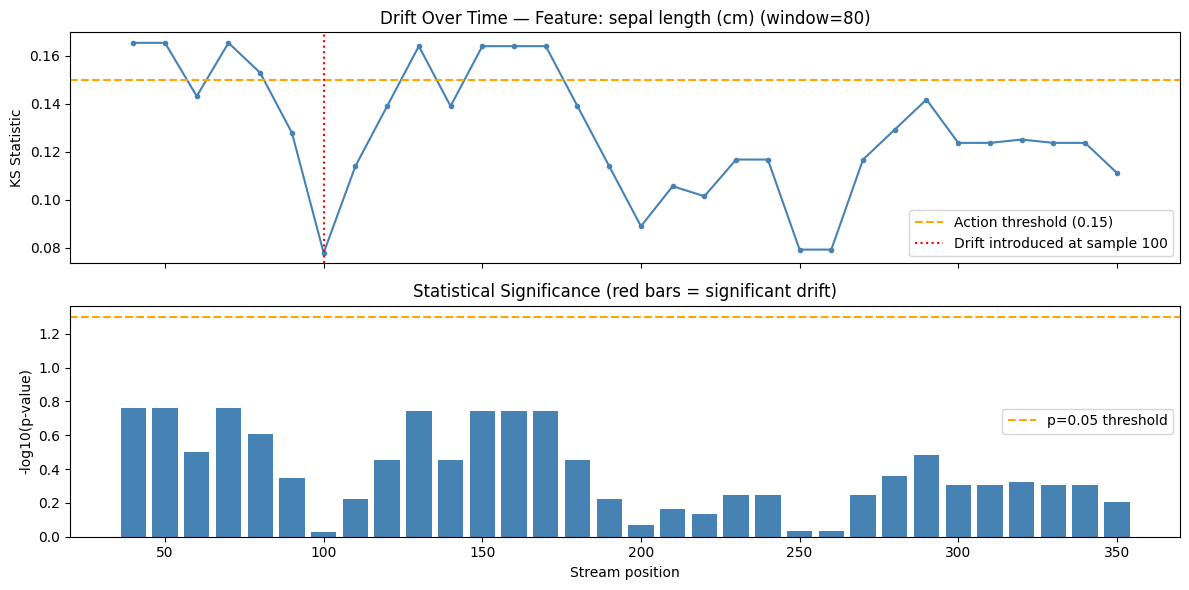

KS statistic rises as drift accumulates. Red bars indicate p < 0.05.


In [4]:
# Generate a longer production stream with drift that starts at sample 100
N_STREAM = 400
n_clean, n_drift = 100, N_STREAM - 100
# X_test is smaller than N_STREAM, so sample with replacement to build the stream.
clean_idx = rng.integers(0, len(X_test), size=n_clean)
drift_idx = rng.integers(0, len(X_test), size=n_drift)
# Drift magnitude grows from 0 to ~1.2 across the drifted segment, so the KS
# statistic rises gradually rather than jumping at a single point.
drift_scale = np.linspace(0.0, 1.2, n_drift).reshape(-1, 1)
X_stream = np.vstack([
    X_test[clean_idx].copy(),                                                   # samples 0-99: no drift
    X_test[drift_idx].copy() + drift_scale * rng.normal(0, 0.5, (n_drift, 4)),  # 100-399: increasing drift
])

WINDOW = 80
FEATURE_IDX = 0  # track sepal length

ks_stats = []
p_values = []
positions = []

reference_feature = X_train[:, FEATURE_IDX]

for start in range(0, N_STREAM - WINDOW, 10):
    window_data = X_stream[start : start + WINDOW, FEATURE_IDX]
    ks, pval = sp_stats.ks_2samp(reference_feature, window_data)
    ks_stats.append(ks)
    p_values.append(pval)
    positions.append(start + WINDOW // 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(positions, ks_stats, color="steelblue", marker="o", markersize=3)
axes[0].axhline(0.15, color="orange", linestyle="--", label="Action threshold (0.15)")
axes[0].axvline(100, color="red", linestyle=":", label="Drift introduced at sample 100")
axes[0].set_ylabel("KS Statistic")
axes[0].set_title(f"Drift Over Time — Feature: {feature_names[FEATURE_IDX]} (window={WINDOW})")
axes[0].legend()

colors = ["red" if p < 0.05 else "steelblue" for p in p_values]
axes[1].bar(positions, [-np.log10(max(p, 1e-10)) for p in p_values], color=colors, width=8)
axes[1].axhline(-np.log10(0.05), color="orange", linestyle="--", label="p=0.05 threshold")
axes[1].set_ylabel("-log10(p-value)")
axes[1].set_xlabel("Stream position")
axes[1].set_title("Statistical Significance (red bars = significant drift)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/drift_over_time.png", dpi=72)
plt.show()
print("KS statistic rises as drift accumulates. Red bars indicate p < 0.05.")

## Section 6 — Jensen-Shannon Divergence

Jensen-Shannon (JS) divergence is a symmetric, bounded (0 to 1) measure of how similar two distributions are. It works well for comparing probability distributions derived from histograms.

In [5]:
# WHAT: compute Jensen-Shannon divergence per feature via shared-bin histograms.
# WHY: unlike the KS p-value, JS is a bounded [0,1] DISTANCE — better for
# dashboards and trend lines because it doesn't saturate with sample size.
from scipy.spatial.distance import jensenshannon


def compute_js_divergence(
    reference: np.ndarray, production: np.ndarray, n_bins: int = 20
) -> float:
    """
    Compute Jensen-Shannon divergence between two 1-D arrays
    by first converting them to histogram-based probability distributions.
    """
    # Use shared bin edges so both histograms are comparable
    combined_min = min(reference.min(), production.min())
    combined_max = max(reference.max(), production.max())
    bins = np.linspace(combined_min, combined_max, n_bins + 1)

    ref_hist,  _ = np.histogram(reference,  bins=bins, density=True)
    prod_hist, _ = np.histogram(production, bins=bins, density=True)

    # Add epsilon to avoid zero probabilities
    eps = 1e-8
    ref_hist  = ref_hist  + eps
    prod_hist = prod_hist + eps

    return float(jensenshannon(ref_hist, prod_hist))


# Same features as the KS table — compare how the two metrics rank the drift.
print("Jensen-Shannon divergence per iris feature:")
print(f"{'Feature':<30} {'JS divergence':<15} {'Interpretation'}")
print("-" * 65)

for i, name in enumerate(feature_names):
    js = compute_js_divergence(X_train[:, i], X_prod[:, i])
    if js < 0.05:
        interpretation = "No drift"
    elif js < 0.15:
        interpretation = "Mild drift"
    else:
        interpretation = "Significant drift"
    print(f"{name:<30} {js:<15.4f} {interpretation}")

print("\nJS divergence is 0 for identical distributions and approaches 1 for completely different ones.")

Jensen-Shannon divergence per iris feature:
Feature                        JS divergence   Interpretation
-----------------------------------------------------------------
sepal length (cm)              0.2509          Significant drift
sepal width (cm)               0.3005          Significant drift
petal length (cm)              0.2465          Significant drift
petal width (cm)               0.3481          Significant drift

JS divergence is 0 for identical distributions and approaches 1 for completely different ones.


## Summary

Three methods for drift detection and when to use each:

| Method | Use for | Key threshold |
|---|---|---|
| **KS test** | Continuous numerical features | p < 0.05 = significant drift |
| **PSI** | Categorical features / prediction class distribution | PSI > 0.2 = action required |
| **JS divergence** | Any distribution comparison; symmetric and bounded | JS > 0.1-0.15 = investigate |

In production: run KS test per numerical feature nightly, PSI on prediction distribution per hour, and alert when any feature crosses the threshold.

## Self-Check (answer before scrolling back up)

1. **What does a KS test p-value of 0.03 tell you?**  
   It means there is only a 3% probability of seeing this level of difference between the two samples if they were actually drawn from the same distribution. Since 0.03 < 0.05, you reject the null hypothesis and conclude that the distributions are significantly different — drift is likely.

2. **Why is PSI used for categorical features rather than KS?**  
   KS is designed for continuous distributions — it relies on the cumulative distribution function, which requires an ordered numerical scale. Categorical variables have no meaningful ordering, so PSI (which works on bin counts / proportions) is more appropriate.

3. **If you detect drift in input features but model accuracy is still high, what does that suggest?**  
   The model is robust to the specific type of shift that has occurred — likely because the decision boundary in the drifted region is still correct. This can happen when drift is in feature dimensions that are not very informative for the prediction task. You should still monitor it, as accuracy may degrade as drift increases.

## 📚 References

1. Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). *A Survey on Concept Drift Adaptation*. ACM Computing Surveys 46(4).
2. Rabanser, S., Günnemann, S., & Lipton, Z. C. (2019). *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS. <https://arxiv.org/abs/1810.11953>
3. Lu, J., Liu, A., Dong, F., Gu, F., Gama, J., & Zhang, G. (2019). *Learning under Concept Drift: A Review*. IEEE TKDE 31(12). <https://arxiv.org/abs/2004.05785>
4. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
